In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Decision Tree
Decision Trees are models that performs in regression and classification tasks.It works with decision rules infered in the data features.the more deeper the tree,more complex it rules

In [2]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_graphviz

iris = load_iris()
x = iris.data[:,1:3]
y = iris.target


tree_clf = DecisionTreeClassifier(max_depth=2)
tree_clf.fit(x,y)

export_graphviz( tree_clf, out_file="iris_tree.dot", feature_names=iris.feature_names[2:], class_names=iris.target_names, rounded=True, filled=True)


image:

[text](iris_tree.dot)

In [3]:
print(tree_clf.predict_proba([[5,1.4]])) #prob of each class 0,1,2
print(tree_clf.predict([[5,1.4]])) #class

[[1. 0. 0.]]
[0]


here,the model separates each class and use decision rules to select the best class based on ou features 2 and 3.

Regression

In [4]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.datasets import load_diabetes

data = load_diabetes(scaled=True,return_X_y=False)
y = data.target
x = data.data

tree_reg = DecisionTreeRegressor(max_depth=2)
tree_reg.fit(x,y)


DecisionTreeRegressor(max_depth=2)

In [5]:
#data moons
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

x,y = make_moons()
x_tr,x_ts,y_tr,y_ts = train_test_split(x,y,test_size=0.2)

## Voting Classifier
The idea behind this type of model is to combine the predicted classes or class proba mean of mutiples models and select the majority class as a final result.

- Soft Voting : uses classes predict proba mean,which can be regulated by weights in each model.
- Hard Voting : uses models predict classes count

In [6]:
from sklearn.ensemble import RandomForestClassifier,VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

#models:
log_rg = LogisticRegression()
rf = RandomForestClassifier()
svm = SVC()

voting_cls = VotingClassifier(
    estimators=[('lg',log_rg),('svm',svm),('rf',rf)],
    voting='hard'
)

voting_cls.fit(x_tr,y_tr)

VotingClassifier(estimators=[('lg', LogisticRegression()), ('svm', SVC()),
                             ('rf', RandomForestClassifier())])

In [7]:
for model in (log_rg,rf,svm,voting_cls):
    model.fit(x_ts,y_ts)
    y_pred = model.predict(x_ts)
    print(model.__class__.__name__,accuracy_score(y_ts,y_pred))

LogisticRegression 0.85
RandomForestClassifier 1.0
SVC 1.0
VotingClassifier 1.0


### Bagging and Pasting 
In a contrary way,we use the same model but with diferents samples.basically we train mutiples estimators of the same model with diferents samples,being bootstrap (bagging) or without reposition (pasting).

bagging uses bootstrap while pasting don't.

with bagging or pasting algorithm,the variance tends to decreases compared with original model.

In [8]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bag_clf = BaggingClassifier(
    DecisionTreeClassifier(),n_estimators=500,
    max_samples=70,bootstrap=True,n_jobs=-1,
    oob_score=True
)

past_clf = BaggingClassifier(
    DecisionTreeClassifier(),n_estimators=100,
    max_samples=70,n_jobs=-1,bootstrap=False,
    
)

bag_clf.fit(x_tr,y_tr)
bag_y_pred = bag_clf.predict(x_ts)

past_clf.fit(x_tr,y_tr)
past_clf_y_pred=past_clf.predict(x_ts)

For bagging,we can also evaluate the _Out of Bag_,which corresponds to the data out of sampling.it happens beacause the bootstrap uses a normal distribuition,where 60%~ of data are in the mean.the out 40%~ are less frequent and the sampling method don't know this data.

In [9]:
##accuracy:
bag_s = accuracy_score(y_ts,bag_y_pred)
past_s = accuracy_score(y_ts,past_clf_y_pred,)


oob_bag = bag_clf.oob_score_
print(f'bag: score= {bag_s},oob= {oob_bag} \n past: score= {past_s}')

bag: score= 1.0,oob= 0.95 
 past: score= 1.0


### Random Forest
The Bagging that you did see above is a model called _Random Forest_.this model basically uses several decision trees with several samples to find best features between data.all it using nodes 

In [10]:
from sklearn.ensemble import RandomForestClassifier

r_forest = RandomForestClassifier(
    n_estimators=500,max_leaf_nodes=16,n_jobs=-1
)

r_forest.fit(x_tr,y_tr)
rf_pred = r_forest.predict(x_ts)
print(f'rf score : {accuracy_score(y_ts,rf_pred)}')

rf score : 1.0


You can either use the bagging alg;

In [11]:
rf_bag = BaggingClassifier(
    DecisionTreeClassifier(splitter='random',
                    max_leaf_nodes=16),n_estimators=500,
    max_samples=1.0,bootstrap=True,n_jobs=-1,
    )

rf_bag.fit(x_tr,y_tr)
rf_bag_pred = rf_bag.predict(x_ts)
print(f'rf bag score : {accuracy_score(y_ts,rf_bag_pred)}')

rf bag score : 1.0


One important thing about Random Forests is that they meansure the importance coeficient of each feature.the model computes the impurity of any feature on nodes and use the weight of each.

In [12]:
from sklearn.datasets import load_iris
iris = load_iris()

rf = RandomForestClassifier(n_estimators=500,n_jobs=-1)

rf.fit(iris['data'],iris['target'])

RandomForestClassifier(n_estimators=500, n_jobs=-1)

In [13]:
for feature,score in zip(iris['feature_names'],rf.feature_importances_):
    print(f'feature: {feature},score: {score}')

feature: sepal length (cm),score: 0.08626884516024835
feature: sepal width (cm),score: 0.021220660689984835
feature: petal length (cm),score: 0.46857058444613015
feature: petal width (cm),score: 0.42393990970363665


### Boosting
If we would use a voting plus a random forest with bagging or pasting?

The boosting algorithms work using a weak learners to combine them in one.each model computes the misclassified previous instances and put weights based in its impurity to make a prediction.the next model after this computes again using previous weights and its predictions.these models are combined sequentially to create a **AdaBoosting**.

we can use the **learning rate** to put the weights of each predictor,like a gradient

In [14]:
from sklearn.ensemble import AdaBoostClassifier

ada_boost = AdaBoostClassifier(
    DecisionTreeClassifier(max_depth=1), #n1--n2,n3 ; one decision rule for each tree
    n_estimators=10,algorithm="SAMME",learning_rate=0.5
)

ada_boost.fit(x_tr,y_tr)

e:\Users\PC\Games\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


AdaBoostClassifier(algorithm='SAMME',
                   estimator=DecisionTreeClassifier(max_depth=1),
                   learning_rate=0.5, n_estimators=10)

In [15]:
for errors,estimator,weights in zip(ada_boost.estimator_errors_,ada_boost.estimators_,
                                           ada_boost.estimator_weights_):
    print(f'''estimator: {estimator},errors: {errors},weights: {weights}''')

estimator: DecisionTreeClassifier(max_depth=1, random_state=1996060149),errors: 0.18750000000000003,weights: 0.7331685343967135
estimator: DecisionTreeClassifier(max_depth=1, random_state=972598718),errors: 0.16627697234711636,weights: 0.8061231700034444
estimator: DecisionTreeClassifier(max_depth=1, random_state=1826185875),errors: 0.24549262125007734,weights: 0.5613990835201644
estimator: DecisionTreeClassifier(max_depth=1, random_state=91452328),errors: 0.21026779882119692,weights: 0.6616559756808672
estimator: DecisionTreeClassifier(max_depth=1, random_state=559169493),errors: 0.24680519571545734,weights: 0.5578622772147774
estimator: DecisionTreeClassifier(max_depth=1, random_state=1945779628),errors: 0.2699285807382185,weights: 0.49749247786929784
estimator: DecisionTreeClassifier(max_depth=1, random_state=85825933),errors: 0.28964859509209073,weights: 0.4485456684588787
estimator: DecisionTreeClassifier(max_depth=1, random_state=1849028439),errors: 0.2943058794729977,weights: 0.

### Gradient Boosting
Instead of using weights of data parts,we could use errors(residuals) of previous models to fit others and combine the predictions of all in one.this is called **Gradient Boosting** were we literaly predict the errors before predict any result.

In [16]:
from sklearn.ensemble import GradientBoostingClassifier

grad_boosting = GradientBoostingClassifier(max_depth=2,n_estimators=100,learning_rate=0.1)
grad_boosting.fit(x_tr,y_tr)

GradientBoostingClassifier(max_depth=2)

In [17]:
grad_y = grad_boosting.predict(x_ts)
print(grad_boosting.train_score_,grad_boosting.feature_importances_)

[1.23561501 1.12049256 1.02493822 0.9419935  0.8704523  0.80815694
 0.75315971 0.70517869 0.66132825 0.62443714 0.58940835 0.55910015
 0.53187115 0.50740453 0.48539247 0.46648861 0.44856373 0.43101825
 0.41554285 0.39985435 0.38141548 0.36749763 0.35234072 0.33924197
 0.32776225 0.31382696 0.30157466 0.2913351  0.28109576 0.2704291
 0.25891725 0.2497281  0.24135698 0.23301923 0.22490597 0.21614041
 0.20927741 0.20179423 0.19390511 0.18699643 0.18075401 0.17472913
 0.16904203 0.16370675 0.15870532 0.15259219 0.14768262 0.14298006
 0.13800955 0.13333464 0.12902193 0.12463545 0.12090108 0.11653002
 0.11266266 0.10891203 0.10578275 0.10238737 0.09887731 0.09637543
 0.09365845 0.09082487 0.08814579 0.0855737  0.0828932  0.08028783
 0.0778813  0.07529823 0.07300383 0.07076958 0.06849809 0.06649363
 0.064522   0.06274862 0.06123315 0.05928904 0.05795556 0.05632822
 0.05511848 0.05356953 0.05203563 0.05050856 0.0490021  0.04755721
 0.04610808 0.04507337 0.0440878  0.04273993 0.04151653 0.04056

We could stop the model when it reachs the minimum error.one way to make it is use early stopping;for gradient boosting,we will use the **staged_predict** which shows the prediction of each estimator:

In [18]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

data = load_diabetes(scaled=True,return_X_y=False)
x,y = data.data,data.target

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2)

grdb = GradientBoostingRegressor(max_depth=2,n_estimators=200)
grdb.fit(x_train,y_train)

errors = [mean_squared_error(y_test,y_pred) for y_pred in 
          grdb.staged_predict(x_test)]

best_n_estimator = np.argmin(errors) + 1 #starts from 0


You could also train the gradient boosting again using the warm_start=True to keep the trees.

In [19]:
gdb = GradientBoostingRegressor(max_depth=2,warm_start=True) # no n_estim because there's not limit

min_error = float('inf')
limit_error_up = 0

for n_estima in range(1,200):
    gdb.fit(x_train,y_train)
    gdb_n = n_estima
    y_pred = gdb.predict(x_test)

    error = mean_squared_error(y_test,y_pred)
    if error < min_error:
        min_error = error
        limit_error_up = 0 #resets
    else:
        limit_error_up +=1
        if limit_error_up == 6:
            break

In [20]:
print(f'min_error,predictor n : {n_estima}')

min_error,predictor n : 7


with the api Xgbrboost,we can also user gradient boosting with early stopping hyperparan

In [33]:
import xgboost

xgboost_alg = xgboost.XGBRegressor(early_stopping_rounds=2)

xgboost_alg.fit(x_train,y_train,
                eval_set=[(x_test,y_test)])

[0]	validation_0-rmse:70.49752
[1]	validation_0-rmse:66.66001
[2]	validation_0-rmse:64.95027
[3]	validation_0-rmse:64.92100
[4]	validation_0-rmse:63.64552
[5]	validation_0-rmse:63.84894
[6]	validation_0-rmse:63.74358


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=2,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [36]:
xgb_predict = xgboost_alg.predict(x_test)

<Axes: ylabel='Count'>

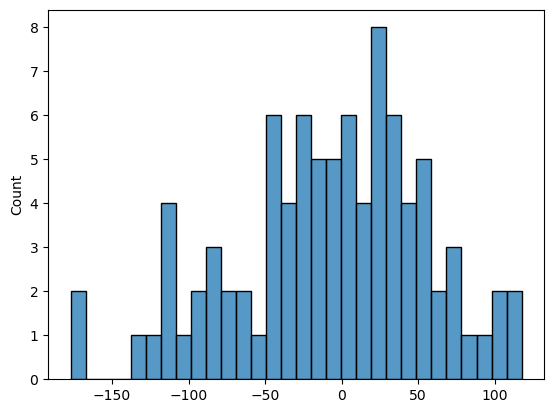

In [44]:
sns.histplot(x=xgb_predict - y_test,bins=30)

### Stacking
We could also combine predictions of models in the previous data and train a new model